# FX Pairs: Feature Engineering

Twenty currency pairs, one decision a day, taken at the New York 5PM close. Every column below
answers one question: at the moment the position is decided, which bars are already on the tape,
and what does the feature make of them?

## Learning objectives

- State how far back a feature reads and how long its inputs take to publish, before writing
  its code
- Aggregate intraday bars onto the decision calendar so a daily feature ends at the 5PM close it
  is decided on, and no later
- Show that withholding later dates leaves every value unchanged, which separates a trailing
  statistic from one fitted over the whole sample
- Read a feature set for scale, dispersion, redundancy and decay before any model sees it

## Book reference, prerequisites and artifacts

Chapter 8, Sections 8.2-8.4, which is also the only prerequisite: this notebook reads four-hour
OANDA spot bars through `load_fx_pairs()` and its settings from `config/setup.yaml`, and reads
nothing another notebook wrote. It writes `features/financial.parquet` with a `.digest.json`
sidecar beside it. [`05_evaluation`](05_evaluation.ipynb) reads that parquet and tests fold by
fold whether any column predicts, as does [`12_model_analysis`](12_model_analysis.ipynb), which
reads it back to attribute what a fitted model used. The six modelling notebooks,
[`06_linear`](06_linear.ipynb) through [`11_causal_dml`](11_causal_dml.ipynb), reach it through
the shared loader `utils.modeling.load_modeling_dataset`, which joins it to the labels and to
the fold-aware features [`04_model_based_features`](04_model_based_features.ipynb) builds from
the same prices.

In [1]:
"""FX Pairs: Feature Engineering."""

import warnings
from datetime import date

import pandas as pd
import polars as pl
import yaml
from IPython.display import display
from ml4t.diagnostic.splitters.calendar import TradingCalendar
from ml4t.engineer.features.momentum import rsi
from ml4t.engineer.features.volatility.garman_klass_volatility import garman_klass_volatility

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.feature_engineering import (
    EPS,
    assert_values_agree,
    assign_families,
    cross_sectional_percentile,
    drawdown_block,
    families_from_config,
    family_coverage,
    momentum_volatility_block,
    plot_coverage_through_time,
    plot_cross_sectional_dispersion,
    plot_feature_distributions,
    plot_persistence,
    plot_redundancy_clusters,
    plot_timing_contract,
    register_frame,
    rolling_zscore,
    warmup_audit,
)
from data import load_fx_pairs
from utils.artifact_specs import resolve_label_horizon
from utils.paths import display_path, get_case_study_dir

warnings.filterwarnings("ignore")

CASE_DIR = get_case_study_dir("fx_pairs")
FEATURES_DIR = CASE_DIR / "features"

One setting is left open for whoever runs the notebook. `START_DATE` of `None` takes the whole
OANDA history, which is what the production run does; a shorter run overrides it through
Papermill to pin the window a reduced dataset covers. There is no cap on how many pairs are
loaded, because the percentile columns need a cross-section to rank within and this universe is
only twenty pairs wide to begin with.

In [2]:
START_DATE = None

## Configuration

Every window, the list of columns that get a percentile, the session calendar and the holdout
boundary live in `config/setup.yaml` and are bound here. The rest of the pipeline reads the same
file, so a number retyped in this notebook would be a second answer to a question that already
has one. What each of them decides is said where it is used; the four printed below set the
shape of everything that follows.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
FAMILIES = families_from_config(setup)
WINDOWS = setup["features"]["windows"]
RANKED = setup["features"]["ranked"]
CARRIER = setup["features"]["null_policy_carrier"]
PERSISTENCE_HORIZON = setup["features"]["persistence_horizon"]
REDUNDANCY_CUT = setup["features"]["redundancy_cut"]
SESSION_CALENDAR = setup["decision"]["session_calendar"]
PERIODS_PER_YEAR = setup["evaluation"]["periods_per_year"]
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])
CYCLE = int(resolve_label_horizon("fx_pairs", setup["labels"]["primary"], setup).rstrip("Dd"))

print(f"{len(FAMILIES)} feature families are declared, and Section A prints what each one claims")
print(f"The position is re-ranked every {CYCLE} session(s), the gap a feature has to survive")
print(f"Rows begin where {CARRIER} can first hold a value, the longest warmup in the matrix")
print(f"Dates from {HOLDOUT_START} are the holdout; Section D rebuilds the panel without them")

8 feature families are declared, and Section A prints what each one claims
The position is re-ranked every 1 session(s), the gap a feature has to survive
Rows begin where zscore_126d can first hold a value, the longest warmup in the matrix
Dates from 2024-01-01 are the holdout; Section D rebuilds the panel without them


## A. What the thesis says should carry information

The strategy is a long-short rank rebalance over twenty pairs, so the hypothesis has to be a
cross-sectional one: a pair stretched against its own recent range comes back relative to the
rest, and how far it can stretch depends on the state the market is in.

That splits the matrix in two, and the register's `role` column is where the split is written
down. A **signal** column is one the ranking may be formed on: the trailing z-score of a
multi-horizon return, and where price sits in the channel it has recently traded through. Which
horizon the effect lives at is an empirical question, so the matrix carries three of each,
alongside the returns they are standardized from - mean reversion and momentum are the same
measurement read with opposite sign. A **state** column describes the environment the ranking is
formed in and is never ranked on: volatility, distance below a trailing peak, the width of the
daily range, the broad dollar. Nothing in a column's values says which of the two it is, so the
role is declared here rather than inferred later.

How a quantity is represented matters as much as the quantity, so eight of the signal and state
columns are carried a second time as percentiles within the decision date, which are comparable
across dates in a way a level is not.

The register is declared in `config/setup.yaml`, one row per family: what it reads, how far
back, with what delay. Every lag is zero - nothing here waits for a publication - and in this
market that is a claim about the session calendar rather than about the vendor, which is what
Section B checks.

In [4]:
register_frame(FAMILIES).select(
    ["family", "role", "driver hypothesis", "inputs", "lookback (bars)", "lag (bars)", "frame"]
)

family,role,driver hypothesis,inputs,lookback (bars),lag (bars),frame
str,str,str,str,i64,i64,str
"""momentum""","""signal""","""A pair that has moved keeps mo…","""daily close""",252,0,"""time series"""
"""risk-adjusted momentum""","""signal""","""Trend earned with less dispers…","""daily log return""",252,0,"""time series"""
"""mean reversion""","""signal""","""A pair stretched against its o…","""daily close""",378,0,"""time series"""
"""volatility""","""state""","""Dispersion sets how far apart …","""daily OHLC""",252,0,"""time series"""
"""range and drawdown""","""state""","""How far a pair sits below its …","""daily OHLC""",63,0,"""time series"""
"""oscillator and trend""","""signal""","""Price against its own recent p…","""daily close""",252,0,"""time series"""
"""dollar factor""","""state""","""A broad dollar move is common …","""daily returns of the seven USD…",315,0,"""cross-asset"""
"""cross-sectional position""","""signal""","""Only relative standing is trad…","""ret_21d, ret_63d, ret_126d, vo…",252,0,"""cross-section"""


## B. Inputs and their observability

Spot FX runs continuously from Sunday evening to Friday evening, so a "day" is a convention
rather than a fact, and the convention has to be the one the decision is taken on.
`config/setup.yaml` fixes it at the New York 5PM rollover and names the venue calendar that
implements it - the same calendar `02_labels` aggregates on.

That aggregation is where a daily FX feature leaks if it is going to. A session is built from the
bars that print inside it and closes on the last of them; a bar one slot later is part of the next
session. It is that boundary, not the calendar date, that makes every feature below knowable at
the decision it is used for, so it is asserted rather than described. The session close is
therefore the last price that printed before the snapshot rather than a price stamped at it: on
US market holidays the feed thins out hours early and the close is whatever traded last, which is
the price a decision taken at the snapshot could actually have seen. The bar timestamp is kept as
`bar_ts` and the open and close are taken by sorting on it, because a group-by does not
contractually preserve row order.

In [5]:
bars = load_fx_pairs(frequency="4h", start_date=START_DATE).select(
    ["symbol", "timestamp", "open", "high", "low", "close", "volume"]
)
sessions = TradingCalendar(SESSION_CALENDAR).get_sessions(
    pd.DatetimeIndex(bars["timestamp"].to_pandas())
)
bars = (
    bars.rename({"timestamp": "bar_ts"})
    .with_columns(pl.Series("timestamp", sessions.values).cast(pl.Date))
    .drop_nulls("timestamp")
)
prices = (
    bars.group_by(["symbol", "timestamp"])
    .agg(
        pl.col("open").sort_by("bar_ts").first().alias("open"),
        pl.col("high").max().alias("high"),
        pl.col("low").min().alias("low"),
        pl.col("close").sort_by("bar_ts").last().alias("close"),
        pl.col("volume").sum().alias("volume"),
        pl.col("bar_ts").max().alias("_last"),
    )
    .sort(["symbol", "timestamp"])
)
assert prices.filter(pl.col("_last").dt.date() > pl.col("timestamp")).height == 0, (
    "a session absorbed a bar dated after its own decision date"
)
# The Garman-Klass variance proxy is non-negative only for a bar whose high and low bracket its
# open and close. A malformed bar would make the window mean negative and its square root arrive
# as a silent null, so the input is checked here rather than the output guarded downstream.
assert prices.select(
    (
        (pl.col("high") >= pl.max_horizontal("open", "close"))
        & (pl.col("low") <= pl.min_horizontal("open", "close"))
    ).all()
).item(), "an OHLC bar does not bracket its own open and close"
prices = prices.drop("_last")
print(f"{len(prices):,} sessions over {prices['symbol'].n_unique()} pairs")
print(f"{prices['timestamp'].min()} to {prices['timestamp'].max()}")

77,480 sessions over 20 pairs
2011-01-03 to 2025-12-31


The twenty pairs are not twenty independent markets, and the way the market groups them is the
way the features below will behave. Seven have the dollar on one of their two legs and share
whatever the dollar does, which is the common component Section C.5 measures. Which leg it is
matters and is not the same across the seven: the dollar is the second currency in `EUR_USD` and
the first in `USD_JPY`, so the same dollar move pushes those two quotes in opposite directions,
and C.5 has to sign each of them before it can average them. Six of the remaining pairs are yen
crosses, which the domestic rate cycle moves together and which travel the widest daily range of
the three groups; the last seven are crosses among the European and Antipodean currencies. Every
pair has the same number of sessions, so the panel is balanced and no feature below has to reason
about a pair joining or leaving part-way through.

The range column is in basis points, hundredths of a percent, which is already a division by the
price level - and that division is why every feature below is a return or a ratio rather than a
price. The pairs are quoted on scales orders of magnitude apart, so a move of one unit means
something different in each of them, and the table shows that even after scaling they do not
travel the same distance in a session.

In [6]:
_base, _quote = pl.col("symbol").str.head(3), pl.col("symbol").str.tail(3)
universe = (
    prices.with_columns(
        pl.when((_base == "USD") | (_quote == "USD"))
        .then(pl.lit("dollar pair"))
        .when((_base == "JPY") | (_quote == "JPY"))
        .then(pl.lit("yen cross"))
        .otherwise(pl.lit("other cross"))
        .alias("block"),
        (1e4 * (pl.col("high") - pl.col("low")) / pl.col("close")).alias("_range_bp"),
    )
    .group_by(["symbol", "block"])
    .agg(
        pl.len().alias("sessions"),
        pl.col("_range_bp").median().round(0).alias("median daily range (bp)"),
    )
    .sort("symbol")
)
with pl.Config(tbl_rows=universe.height):
    display(universe)

symbol,block,sessions,median daily range (bp)
str,str,u32,f64
"""AUD_JPY""","""yen cross""",3874,97.0
"""AUD_NZD""","""other cross""",3874,54.0
"""AUD_USD""","""dollar pair""",3874,88.0
"""CAD_JPY""","""yen cross""",3874,88.0
"""CHF_JPY""","""yen cross""",3874,73.0
"""EUR_AUD""","""other cross""",3874,75.0
"""EUR_CAD""","""other cross""",3874,66.0
"""EUR_CHF""","""other cross""",3874,42.0
"""EUR_GBP""","""other cross""",3874,59.0


## C. Feature construction, one subsection per family

### C.1 Momentum, volatility and their differences

Three quantities come out of the same trailing window and a shared helper computes them
together: the return over the window, the annualized standard deviation of the daily log returns
inside it, and the ratio of the two, which is a trailing Sharpe ratio. Reading the same window
three ways separates a move that was steady from one that was a single jump.

What stays local is specific to this universe. `mom_skip_recent` is the return over a year that
stops a month short of the decision, because the most recent month of an FX move is the part
most likely to reverse, and leaving it out asks whether the slower trend is still there.
`accel_21_63` and `accel_63_126` are differences between horizons, and say whether a trend is
speeding up or bleeding away.

In [7]:
def momentum_features(df: pl.DataFrame) -> pl.DataFrame:
    """The shared trailing block, plus the differences this case study builds on it."""
    df = momentum_volatility_block(
        df,
        entity="symbol",
        return_windows=WINDOWS["momentum"],
        volatility_windows=WINDOWS["close_to_close_volatility"],
        periods_per_year=PERIODS_PER_YEAR,
    ).rename({f"vol_{w}d": f"vol_cc_{w}d" for w in WINDOWS["close_to_close_volatility"]})
    held = pl.col("close").shift(WINDOWS["skip_recent"]).over("symbol")
    start = pl.col("close").shift(WINDOWS["momentum"][-1]).over("symbol")
    return df.with_columns(
        (held / start.clip(lower_bound=EPS) - 1).alias("mom_skip_recent"),
        (pl.col("ret_21d") - pl.col("ret_63d")).alias("accel_21_63"),
        (pl.col("ret_63d") - pl.col("ret_126d")).alias("accel_63_126"),
    )

### C.2 Garman-Klass volatility

A close-to-close deviation sees two prices a session apart and discards everything that happened
between them, so a session that travelled a long way and came back reads as quiet. The
Garman-Klass estimator uses all four prices in the bar, combining the high-to-low range with the
open-to-close move:

$$\sigma^2_{GK} = \tfrac{1}{2}\left(\ln\tfrac{H}{L}\right)^2 - (2\ln 2 - 1)\left(\ln\tfrac{C}{O}\right)^2$$

For a session of the same true volatility that is several times less noisy than the
close-to-close estimate, which is why Chapter 8 uses it here: the range is where most of an FX
session's information about dispersion sits. The columns carry the square root of the window
mean of that variance, annualized, so they are on the same scale as the close-to-close deviation
beside them. The two ratios read the regime rather than the level - a short window against a
longer one says whether dispersion is rising or falling, which no single window can.

In [8]:
def volatility_features(df: pl.DataFrame) -> pl.DataFrame:
    """Garman-Klass deviation at four windows, and the two ratios between them."""
    short, mid, long = (WINDOWS["garman_klass"][i] for i in (0, 1, -1))
    return df.with_columns(
        garman_klass_volatility(
            "open", "high", "low", "close", period=w, trading_periods=PERIODS_PER_YEAR
        )
        .over("symbol")
        .alias(f"vol_gk_{w}d")
        for w in WINDOWS["garman_klass"]
    ).with_columns(
        (pl.col(f"vol_gk_{short}d") / pl.col(f"vol_gk_{mid}d").clip(lower_bound=EPS)).alias(
            f"vol_ratio_{short}_{mid}"
        ),
        (pl.col(f"vol_gk_{mid}d") / pl.col(f"vol_gk_{long}d").clip(lower_bound=EPS)).alias(
            f"vol_ratio_{mid}_{long}"
        ),
    )

### C.3 Mean reversion: z-scores, channel position and Bollinger %B

These are the columns the ranking is formed on. Each multi-horizon return is standardized
against its own trailing year, so the z-score says how unusual the move is for that pair rather
than how large it is in price terms. The universe table above is the reason that matters: the
same move is unremarkable in a pair that travels the widest daily range here and a large one in
the pair that travels the narrowest, and standardizing each pair against its own history is what
makes the two comparable on the day the ranking is formed.

Channel position and Bollinger %B ask the same question of the level instead of the change:
where does price sit in the range it has recently traded through? Channel position measures that
against the highest and lowest close of the window, so it reads zero at the bottom of the range
and one at the top. Bollinger bands replace the range with a moving average of the close plus
and minus two standard deviations of it, so the band widens when the pair is volatile instead of
staying pinned by one old extreme for the length of the window. %B is where the close sits
between the two bands, on the same zero-to-one reading:

$$\%B = \frac{C - (\mu - 2\sigma)}{4\sigma}$$

It leaves that interval whenever price is more than two deviations away from the average, which
is why the column runs a little below zero and a little above one rather than stopping at the
ends. All three are trailing statistics within one pair, so nothing here is estimated across
pairs or across the sample.

In [9]:
def mean_reversion_features(df: pl.DataFrame) -> pl.DataFrame:
    """Trailing z-scores of the multi-horizon returns, and two range positions."""
    bb, close = WINDOWS["bollinger"], pl.col("close")
    hi = {w: close.rolling_max(w).over("symbol") for w in WINDOWS["channel"]}
    lo = {w: close.rolling_min(w).over("symbol") for w in WINDOWS["channel"]}
    mid = close.rolling_mean(bb).over("symbol")
    sd = close.rolling_std(bb).over("symbol")
    return df.with_columns(
        *[
            rolling_zscore(f"ret_{h}d", WINDOWS["zscore"], "symbol").alias(f"zscore_{h}d")
            for h in WINDOWS["zscore_horizons"]
        ],
        *[
            ((close - lo[w]) / (hi[w] - lo[w]).clip(lower_bound=EPS)).alias(f"channel_pos_{w}d")
            for w in WINDOWS["channel"]
        ],
        pl.when(sd > 0).then((close - (mid - 2 * sd)) / (4 * sd)).alias(f"bollinger_pctb_{bb}d"),
    )

### C.4 Drawdown, range and oscillators

`max_dd_63d` is the share by which price sits below its highest close of the trailing quarter,
so it is zero at a new high and negative otherwise. That is the *current* drawdown and not the
worst peak-to-trough decline anywhere inside the window: the two are different statistics, and a
pair that sold off early in the quarter and then made the whole move back scores nothing on the
current drawdown and its full decline on the worst one.

The relative strength index, RSI, compares how much price gained on the sessions that closed up
with how much it lost on the sessions that closed down over a trailing window, and maps the
comparison onto a nought-to-hundred scale where fifty is as much up move as down. The averaging
is Wilder's recursive one, which folds each new session into the running average with weight
`1/period` rather than taking a plain mean of the last `period` sessions; the two give different
numbers on the same data, and Wilder's is the convention the library implements.

The last two families are plainer. `avg_range_*` is the high-to-low range as a share of the
close, averaged over the window, which says how far a pair typically travels within a session.
`price_to_ma_*` is how far price sits above or below its own moving average.

In [10]:
def drawdown_range_and_oscillators(df: pl.DataFrame) -> pl.DataFrame:
    """Distance below the trailing peak, normalized range, RSI and trend ratios."""
    close = pl.col("close")
    rng = (pl.col("high") - pl.col("low")) / close.clip(lower_bound=EPS)
    return drawdown_block(df, entity="symbol", windows=WINDOWS["drawdown"]).with_columns(
        *[rng.rolling_mean(w).over("symbol").alias(f"avg_range_{w}d") for w in WINDOWS["range"]],
        *[rsi("close", period=p).over("symbol").alias(f"rsi_{p}d") for p in WINDOWS["rsi"]],
        *[
            (close / close.rolling_mean(w).over("symbol").clip(lower_bound=EPS) - 1).alias(
                f"price_to_ma_{w}d"
            )
            for w in WINDOWS["moving_average"]
        ],
    )

### C.5 The dollar factor

Seven of the twenty pairs have the dollar on one leg and share a common component that is not
pair-specific. The proxy is a signed average of those seven returns, and the sign is what Section
B flagged: a rise in `EUR_USD` is a falling dollar and a rise in `USD_JPY` is a rising one, so a
pair quoting the dollar second enters the average with its return negated. The seven are found
from the symbols themselves rather than from a list typed here, so the proxy follows the universe.

It is a transparent average and not an estimated factor: no loading is fitted and nothing is
regressed. The average is over log returns, so accumulating it over a horizon is a sum and the
aggregates are the proxy's own cumulative move rather than an approximation of one.

How much each pair moves with the proxy is then a rolling correlation over the trailing year,
reading the pair's history and the proxy's, both ending at the decision. A correlation and not a
regression slope, which is what the column name has to say: `usd_corr_63d` runs between minus
one and one and reports how *reliably* the pair tracks the dollar, where a beta would report by
how much and would move with the pair's own volatility whether or not the relationship changed.
The frame is re-sorted after the join: a rolling window reads row order rather than the
timestamp column, and a join promises nothing about order.

In [11]:
def dollar_factor(df: pl.DataFrame) -> pl.DataFrame:
    """The signed dollar proxy at three horizons, and each pair's correlation with it."""
    base, quote = pl.col("symbol").str.head(3), pl.col("symbol").str.tail(3)
    signed = (
        df.filter((base == "USD") | (quote == "USD"))
        .with_columns(
            pl.when(base == "USD")
            .then(pl.col("log_return"))
            .otherwise(-pl.col("log_return"))
            .alias("_usd")
        )
        .group_by("timestamp")
        .agg(pl.col("_usd").mean().alias("usd_factor_1d"))
        .sort("timestamp")
    )
    signed = signed.with_columns(
        pl.col("usd_factor_1d").rolling_sum(h).alias(f"usd_factor_{h}d") for h in WINDOWS["dollar"]
    )
    return (
        df.join(signed, on="timestamp", how="left")
        .sort(["symbol", "timestamp"])
        .with_columns(
            pl.rolling_corr(
                pl.col(f"ret_{h}d"),
                pl.col(f"usd_factor_{h}d"),
                window_size=WINDOWS["dollar_exposure"],
            )
            .over("symbol")
            .alias(f"usd_corr_{h}d")
            for h in WINDOWS["dollar"]
        )
    )

### C.6 Cross-sectional position, and the whole construction

The ranked columns become percentiles within their own decision date. The strategy is long-short
over a ranking, so relative standing is what it can act on, and a percentile is comparable across
dates in a way a level is not. The partition is the decision timestamp and nothing else, so the
statistic reads twenty rows and no other date.

In [12]:
def build_features(df: pl.DataFrame) -> pl.DataFrame:
    """The whole construction, as one function Section D can re-run on a shorter panel.

    The last step converts NaN to null. Some library calls fill their warmup with NaN and
    others with null, and a NaN is a missing value dressed as a number: `is_not_null` reads
    it as present, so the warmup audit and the coverage figure would score an empty stretch
    as covered.
    """
    df = (
        df.pipe(momentum_features)
        .pipe(volatility_features)
        .pipe(mean_reversion_features)
        .pipe(drawdown_range_and_oscillators)
        .pipe(dollar_factor)
        .with_columns(
            cross_sectional_percentile(col, "timestamp").alias(f"rank_{col}") for col in RANKED
        )
    )
    return df.with_columns(pl.col(pl.Float32, pl.Float64).fill_nan(None))


EXCLUDED = {"symbol", "timestamp", "open", "high", "low", "close", "volume", "log_return"}
built = build_features(prices)
feature_cols = [c for c in built.columns if c not in EXCLUDED]
print(f"{len(built):,} sessions carrying {len(feature_cols)} features")

77,480 sessions carrying 53 features


## D. The timing contract

Each feature makes two promises about time: how many bars back it reads, and how long its inputs
take to become available after the period they describe. Together those fix the earliest decision
the feature can be used at, and they are what the register declares in Section A. This section
checks all three - what the constructions actually read, that no column fills before its window
could have, and that no value depends on a date after it.

### D.1 What each construction reads

Three kinds of operation appear above. A **rolling** window ends at its own row and reads a fixed
number of bars backward within one pair. A **cross-sectional** statistic - the percentiles and
the dollar proxy - is taken over the decision timestamp, so it reads every pair on that date and
no other. A **join** broadcasts the proxy back to the panel and is followed by an explicit sort,
so the rolling correlation that reads it sees the order it assumes.

The figure below draws the register: each bar runs leftward from the decision by the number of
sessions that family reads, and stops where its oldest input sits. What to look for is the right
edge. A family whose input is published with a delay - a survey, a restated fundamental, an
exchange file that lands the next morning - would end short of the line by the length of that
delay, and everything between the two would be information the decision cannot have. Every input
here is a spot bar already on the tape at the 5PM close, so every bar reaches the line.

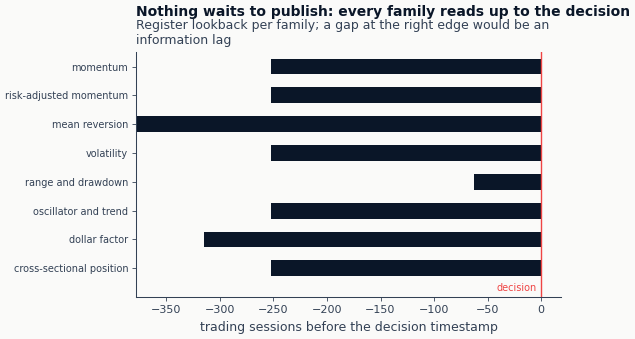

In [13]:
plot_timing_contract(
    FAMILIES,
    bar_unit="trading sessions",
    title="Nothing waits to publish: every family reads up to the decision",
    subtitle="Register lookback per family; a gap at the right edge would be an information lag",
    alt=(
        "Horizontal bars, one per family, each extending leftward from the decision line by that "
        "family's declared lookback - shortest for range and drawdown, longest for the dollar "
        "factor and mean reversion. Every bar reaches the line, so no family shows a lag gap."
    ),
)

### D.2 Warmup

A trailing window cannot produce a value until it has enough bars to fill. The audit checks that
length rather than describing it: a column carrying a value before its window could have filled
is reading bars that do not exist, and that is what it raises on. The two longest are chains
rather than single windows - `zscore_126d` standardizes a return against a further year of them,
and `usd_corr_63d` correlates a horizon return over a year of sessions. The census it returns
shows, per column, the warmup declared for it and the bar it actually first held a value on; a
column may fill later than its window if the pair's own history is short, and never earlier.

In [14]:
warmup_audit(
    built,
    {
        "zscore_126d": WINDOWS["zscore"] + WINDOWS["zscore_horizons"][-1],
        "usd_corr_63d": WINDOWS["dollar_exposure"] + WINDOWS["dollar"][-1],
        "ret_252d": WINDOWS["momentum"][-1],
        "sharpe_252d": WINDOWS["momentum"][-1],
        "vol_gk_252d": WINDOWS["garman_klass"][-1],
        "price_to_ma_252d": WINDOWS["moving_average"][-1],
        "channel_pos_126d": WINDOWS["channel"][-1],
        "max_dd_63d": WINDOWS["drawdown"][0],
        "rsi_14d": WINDOWS["rsi"][0],
    },
    entity="symbol",
)

column,declared warmup (bars),first populated bar,populated
str,i64,i64,bool
"""zscore_126d""",378,378,true
"""usd_corr_63d""",315,315,true
"""ret_252d""",252,253,true
"""sharpe_252d""",252,253,true
"""vol_gk_252d""",252,252,true
"""price_to_ma_252d""",252,252,true
"""channel_pos_126d""",126,126,true
"""max_dd_63d""",63,63,true
"""rsi_14d""",14,15,true


### D.3 Withholding the holdout changes nothing

Trailing and within-date statistics share a property worth checking directly: recomputed on a
panel that stops before the holdout, they reproduce the same values on the rows the two panels
share. A parameter fitted over a whole column - a winsorization bound, a scaler, an encoder -
does not, because truncating the column moves the parameter and with it every row it was applied
to. Building the panel twice and comparing tests the whole construction at once, every emitted
column rather than a sample, and does not depend on anyone having flagged the transform that
fits. A value on one side against a null on the other counts as a difference, which is the form
of failure a null-skipping comparison hides.

The comparison raises if any column moves, so reaching the next cell is the result. Three rows of
it are shown - one trailing statistic, one percentile taken within a date, one rolling
correlation - each reporting how many rows were compared and the largest gap found between the
two builds.

In [15]:
seal = assert_values_agree(
    built.filter(pl.col("timestamp") < HOLDOUT_START),
    build_features(prices.filter(pl.col("timestamp") < HOLDOUT_START)),
    columns=feature_cols,
    keys=["timestamp", "symbol"],
)
seal.filter(pl.col("column").is_in(["zscore_126d", "rank_ret_126d", "usd_corr_63d"]))

column,rows compared,null only on one side,max abs difference
str,i64,i64,f64
"""zscore_126d""",67100,0,0.0
"""usd_corr_63d""",67100,0,0.0
"""rank_ret_126d""",67100,0,0.0


## E. Matrix assembly and coverage

The panel key is `symbol` + `timestamp`. Raw OHLC, volume and the intermediate log return are
excluded: they are the inputs the features are made of, and the log return dated `t` is the
primary label dated one session earlier, so a model handed it beside that label would be reading
an answer it was asked for one row before. The shortest trailing return the matrix ships spans a
trading week.

One null policy is applied once, and it is a cut rather than a fill: nothing is imputed,
forward-filled or zero-filled, because a filled warmup value is a number the window never
produced. A pair's rows start where the column with the longest chain of trailing windows can
first hold a value - the 126-session z-score, which then needs a further trailing year to
standardize against - and every shorter window has filled by then. The assertion below makes
that a fact rather than an intention.

In [16]:
features = (
    built.select(["timestamp", "symbol", *feature_cols])
    .drop_nulls(subset=[CARRIER])
    .sort(["timestamp", "symbol"])
)
assert features.select(["timestamp", "symbol"]).is_duplicated().sum() == 0, "duplicate panel key"
assert features.null_count().sum_horizontal().item() == 0, "the null policy left a gap behind"
assignment = assign_families(feature_cols, FAMILIES)
print(
    f"{len(feature_cols)} features, {len(features):,} rows, {features['symbol'].n_unique()} pairs"
)
print(f"{features['timestamp'].min()} to {features['timestamp'].max()}")
print(f"null policy dropped {len(built) - len(features):,} warmup rows")
register_frame(FAMILIES, feature_cols).select(["family", "columns", "role", "representation"])

53 features, 69,940 rows, 20 pairs
2012-06-19 to 2025-12-31
null policy dropped 7,540 warmup rows


family,columns,role,representation
str,i64,str,str
"""momentum""",10,"""signal""","""simple return, and differences…"
"""risk-adjusted momentum""",7,"""signal""","""mean log return over its own d…"
"""mean reversion""",7,"""signal""","""trailing z-score, position in …"
"""volatility""",8,"""state""","""Garman-Klass and close-to-clos…"
"""range and drawdown""",3,"""state""","""share below the trailing peak,…"
"""oscillator and trend""",5,"""signal""","""Wilder-smoothed oscillator, ra…"
"""dollar factor""",5,"""state""","""signed average return, and eac…"
"""cross-sectional position""",8,"""signal""","""percentile within the decision…"


The matrix carries **53 features** on **69,940 rows** across **20 pairs**, from **2012-06-19** to
**2025-12-31**. The null policy costs **7,540 rows**, every one of them inside the warmup stretch
at the start of a pair's history.

### F1. Coverage through time

Drawn on the panel *before* the null policy, so the figure shows what the policy is for. Each
family climbs to complete coverage as its longest window fills, and the dashed boundary marks
the first session the emitted matrix keeps. Read the two halves separately: the ramp to the left
of the boundary is the stretch the policy removes, and the flat run at one to the right of it is
the assertion in the cell above, drawn month by month.

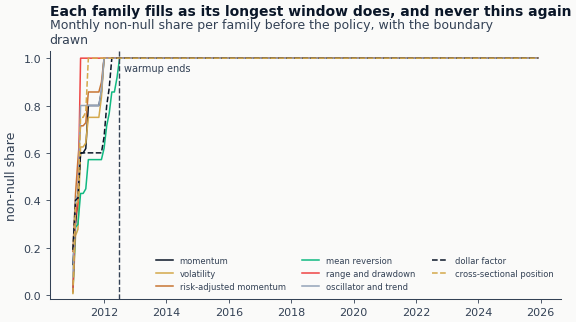

In [17]:
plot_coverage_through_time(
    family_coverage(built.select(["timestamp", *feature_cols]), assignment, every="1mo"),
    warmup_boundary=features["timestamp"].min(),
    title="Each family fills as its longest window does, and never thins again",
    subtitle="Monthly non-null share per family before the policy, with the boundary drawn",
    alt=(
        "Non-null share by feature family, on an axis from zero to one. Every family starts at "
        "zero and climbs to one during the first eighteen months as its longest window fills, "
        "the short-window families first and mean reversion last. A dashed line in mid-2012 marks "
        "where the null policy starts, and every line is flat at one from there to the end."
    ),
)

## F. What the features look like

Four properties decide whether this matrix can be used at all: the scale each feature arrives on,
whether the cross-section disagrees enough to rank on, how much of the set is one ordering under
several names, and how long a value lasts. `05_evaluation` is where the matrix is tested fold by
fold for whether any of it predicts.

### F2. Feature distributions

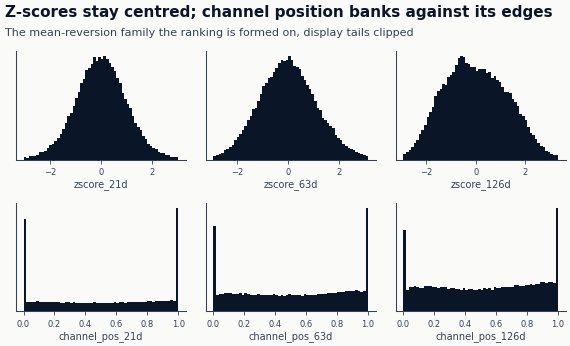

In [18]:
plot_feature_distributions(
    features,
    ["zscore_21d", "zscore_63d", "zscore_126d"] + [f"channel_pos_{w}d" for w in WINDOWS["channel"]],
    title="Z-scores stay centred; channel position banks against its edges",
    subtitle="The mean-reversion family the ranking is formed on, display tails clipped",
    alt=(
        "Six histograms in two rows. The top row holds the trailing z-scores of the three "
        "horizon returns, each a broad single-peaked body roughly centred on zero. The bottom row "
        "holds channel position at the same windows, bounded by zero and one with mass banked "
        "against both ends."
    ),
)

### F3. Cross-sectional dispersion through time

A cross-sectional strategy needs the cross-section to disagree. On a date where the band narrows
to nothing there is nothing to rank, whatever the average level of the feature. That never
happens here, which is the necessary condition rather than a promising one: a band this wide says
a ranking exists to be formed, not that it predicts anything.

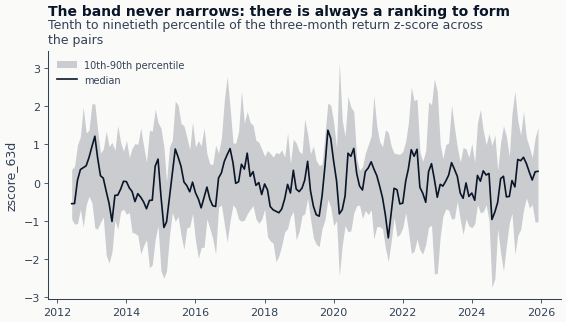

In [19]:
plot_cross_sectional_dispersion(
    features,
    "zscore_63d",
    every="1mo",
    title="The band never narrows: there is always a ranking to form",
    subtitle="Tenth to ninetieth percentile of the three-month return z-score across the pairs",
    alt=(
        "Shaded band of the tenth to ninetieth percentile of the three-month return z-score by "
        "month, with the median drawn through it. The band is between two and three units wide in "
        "every year of the sample and never approaches zero width. The median wanders between "
        "roughly minus one and plus one and a half, and shows no trend."
    ),
)

### F5. Redundancy structure

Two columns are redundant when they carry the same ordering, however different their formulas
look, so the distance clustered on is $1 - |\rho_s|$: $\rho_s$ is the rank correlation between
the pair of columns, and taking its absolute value treats a feature and its negation as the same
thing. The tree is cut at the rank correlation the configuration declares, drawn as the dashed
line and named in the subtitle. Linkage is average, so a cluster is a group whose members are
that close to each other *on average*, not one in which every pair clears the threshold. Read it
as a screen for duplication and nothing stronger: these columns largely agree about which pair is
high and which is low, which is a reason to suspect they are one measurement under several names.

What the tree groups on is the horizon rather than the family. The three largest
clusters are the short, medium and long windows, and each one mixes families freely: the
short-window cluster holds the return, the risk-adjusted return, the z-score, the channel
position, Bollinger %B, the oscillator, the trend ratio and both percentile columns, all at
roughly a month. A pair of columns crosses horizons - the quarterly drawdown joins the medium
cluster and the longer oscillator the long one - which is the tree saying those two read the same
ordering as a different window's family, not as their own.

The volatility columns are the exception and cluster with each other across every window rather
than with the signals beside them. What stays out is worth as much as what joins: three
dollar-factor aggregates, two volatility ratios, two acceleration columns and the longest z-score
each sit alone above the cut, so they are the only columns in the matrix carrying an ordering no
other column repeats. Which member of a cluster to keep is a question the tree cannot answer,
because it needs a criterion measured out of sample; `05_evaluation` measures one fold by fold.

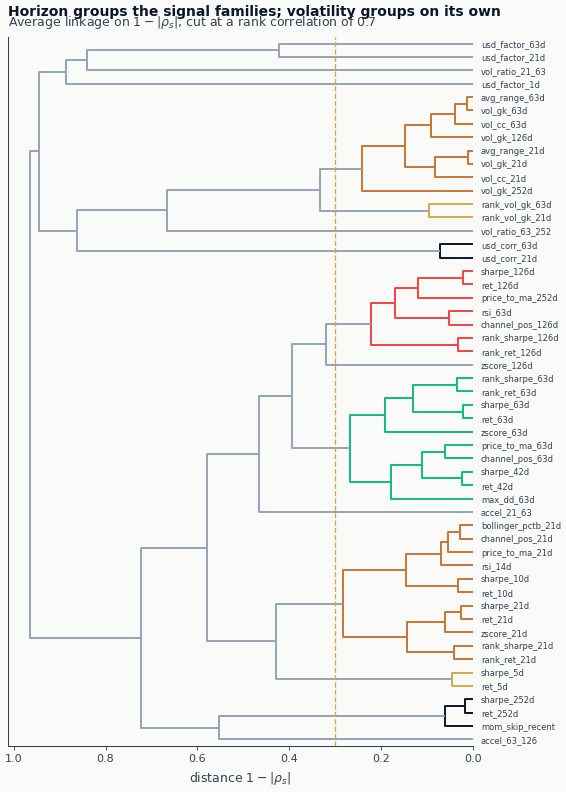

16 redundancy clusters at the drawn cut


In [20]:
clusters = plot_redundancy_clusters(
    features,
    feature_cols,
    cut=REDUNDANCY_CUT,
    title="Horizon groups the signal families; volatility groups on its own",
    subtitle=(
        r"Average linkage on $1 - |\rho_s|$, cut at a rank correlation of "
        f"{REDUNDANCY_CUT}"
    ),
    alt=(
        "Dendrogram of every feature in the matrix. Three large clusters each hold one horizon "
        "and mix every signal family in it: the short-window return, risk-adjusted return, "
        "z-score, channel position, Bollinger %B, oscillator, trend ratio and percentile columns "
        "join together, and the medium and long windows do the same. A fourth cluster holds the "
        "volatility levels and the average range from every window. Eight columns sit alone above "
        "the cut - the three dollar-factor aggregates, the two volatility ratios, the two "
        "acceleration columns and the 126-session z-score."
    ),
)
print(f"{len(set(clusters.values()))} redundancy clusters at the drawn cut")

Cutting the redundancy tree leaves **16 clusters** for **53 features**, so most of the matrix
repeats an ordering another column already carries.

### F6. Persistence and rank stability

The cadence is daily, so the right panel compares the ordering across consecutive sessions, the
schedule the strategy rebalances on. At that cadence the panel separates nothing - one session is
short enough that every feature keeps its ordering - and the left panel is what carries the
information: the autocorrelation of the feature itself, run out to a quarter. It is estimated per
pair on sessions exactly one lag apart and summarized by the median over pairs, with a bootstrap
interval over pairs; a correlation pooled over every pair-date would read high whenever pairs sit
at different levels, whether or not any one of them persists. Read that way the figure says which
columns are state and which are signal, and it puts the short z-score at zero at a lag equal to
its own window - a value that has nothing left to say about the one before it.

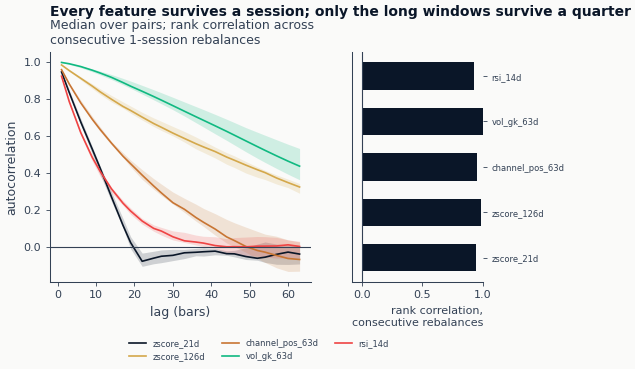

In [21]:
plot_persistence(
    features,
    ["zscore_21d", "zscore_126d", "channel_pos_63d", "vol_gk_63d", "rsi_14d"],
    entity="symbol",
    max_lag=PERSISTENCE_HORIZON,
    decision_dates=features["timestamp"].unique().sort().to_list(),
    title="Every feature survives a session; only the long windows survive a quarter",
    subtitle=f"Median over pairs; rank correlation across consecutive {CYCLE}-session rebalances",
    alt=(
        "Two panels. On the left, autocorrelation against lag out to a quarter. Three-month "
        "Garman-Klass volatility decays slowest and is still near a half at the right edge, the "
        "126-session z-score is around a third, and the 63-session channel position, the "
        "21-session z-score and the 14-day oscillator have all reached zero by then - the short "
        "z-score crossing zero at a lag equal to its own window and staying slightly negative. "
        "The bootstrap ribbons are narrow throughout. On the right, the cross-sectional rank "
        "correlation between consecutive sessions is close to one for all five features, with "
        "volatility highest and the oscillator lowest."
    ),
)

## G. Emit

The parquet is written with a sidecar beside it, a small JSON file. The sidecar records a hash of
the table's contents, alongside its row count, its key columns and the same hash taken over the
price panel the table was built from. The hash is over values rather than over the bytes of the
file, so re-writing the parquet, reordering its rows or changing how it is compressed leaves the
hash alone, while any change to a single feature value moves it. That is what makes "the artifact
on disk is the one this code produces" a question anyone can settle by reading two files, instead
of re-deriving the table and comparing it column by column.

In [22]:
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
record = write_artifact(
    features,
    FEATURES_DIR / "financial.parquet",
    keys=["symbol", "timestamp"],
    written_by="case_studies/fx_pairs/03_financial_features.py",
    inputs={"load_fx_pairs:4h": value_digest(prices)},
)
print(f"Wrote {display_path(FEATURES_DIR / 'financial.parquet')} under digest {record['digest']}")

Wrote case_studies/fx_pairs/features/financial.parquet under digest eb03ef1598526b89


## Key takeaways

- **Declare how far back each feature reads before writing it.** The configuration holds one
  lookback and one lag per family, and the warmup assertion, the timing figure and the register
  table all read those declared numbers instead of re-deriving them from the code, so a window
  that disagrees with what was promised raises rather than passing quietly.
- **In a market that never closes, the aggregation is what makes a feature knowable.** A daily FX
  feature is available at its decision only because the session boundary is the same rollover the
  decision is taken at, which is why Section B asserts that boundary rather than describing it.
- **Check for a fitted transform by rebuilding, not by reading.** Recomputing the whole panel with
  the later dates removed and comparing value by value catches anything estimated across the
  sample, including the transforms nobody thought to flag.
- **Read the matrix before modelling it.** Distribution, dispersion, redundancy and decay each
  rule out a use: a feature with no cross-sectional spread cannot rank, and one whose ordering
  decays inside the rebalance cycle cannot be traded at that cadence.

### Known limitations

- There is no carry feature, and carry is the most thoroughly documented effect in this asset
  class. It needs the interest-rate differential between the two legs, which the OANDA spot feed
  does not carry, so the matrix says nothing about the return a position earns for being held.
  Every conclusion drawn downstream is a conclusion about spot dynamics alone.
- The dollar proxy is an equal-weighted signed average of seven pairs, not an estimated factor.
  It says nothing about the euro or yen blocs, which the crosses here load on as heavily.
- Volume on a spot feed is tick count at one venue rather than traded notional, so it is used
  only through the daily range and not as a participation feature.
- Every feature here is a rule written in advance. `04_model_based_features` adds the features
  that are themselves model outputs, where the rule is estimated from the data.